<a href="https://colab.research.google.com/github/Immaniyelu2001/projects_v/blob/main/Braintumor_yolo11n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics

In [2]:
import zipfile

zip_path = "/content/dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [3]:
import os
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import yaml

train_path = "/content/dataset/Train"
val_path = "/content/dataset/Val"

In [4]:
classes = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]

def load_data(data_path):
    images = []
    labels = []
    for class_label in classes:
        class_path = os.path.join(data_path, class_label, 'images')
        label_path = os.path.join(data_path, class_label, 'labels')
        for img_file in os.listdir(class_path):
            img = cv2.imread(os.path.join(class_path, img_file))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            label_file = img_file.replace('.jpg', '.txt')
            label_file_path = os.path.join(label_path, label_file)
            if os.path.exists(label_file_path):
                with open(label_file_path, 'r') as f:
                    label_data = f.readline().strip().split()
                    if len(label_data) > 0:
                        images.append(img)
                        labels.append(label_data)
                    else:
                        print(f"Label file {label_file_path} is empty, skipping this image.")
            else:
                print(f"Label file {label_file_path} not found, skipping this image.")
    return images, labels

train_images, train_labels = load_data(train_path)
val_images, val_labels = load_data(val_path)

Label file /content/dataset/Val/Glioma/labels/gg (342).txt is empty, skipping this image.
Label file /content/dataset/Val/No Tumor/labels/image(55).txt not found, skipping this image.
Label file /content/dataset/Val/No Tumor/labels/image(61).txt not found, skipping this image.


In [5]:
import yaml

dataset_yaml = {
    'path': '/content/dataset',   # your dataset folder
    'train': 'Train',
    'val': 'Val',
    'names': classes
}

with open('/content/dataset.yaml', 'w') as file:
    yaml.dump(dataset_yaml, file, default_flow_style=False)


In [6]:
model = YOLO("yolo11n.pt")

In [7]:
model.train(data='/content/dataset.yaml', epochs=35, imgsz=640,patience=7)

Ultralytics 8.3.248 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=7, perspective=0.0, plots=True, pose=12.0, pre

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e250c175130>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [8]:
metrics = model.val(split='val')

print(f"Mean Average Precision @.5:.95 : {metrics.box.map}")
print(f"Mean Average Precision @ .50   : {metrics.box.map50}")
print(f"Mean Average Precision @ .70   : {metrics.box.map75}")
print("recall : ",metrics.box.r)
print(metrics.box.f1)
print(metrics.box.maps)

Ultralytics 8.3.248 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 825.8±375.5 MB/s, size: 21.0 KB)
val: Scanning /content/dataset/Val/Glioma/labels.cache... 510 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 512/512 864.2Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 4.6it/s 7.0s
                   all        512        554      0.956      0.936      0.964      0.796
                Glioma        135        153      0.933      0.876      0.941      0.765
            Meningioma        140        142      0.993      0.992      0.995      0.848
              No Tumor         98         98       0.98      0.987      0.976      0.824
             Pituitary        154        161      0.916      0.888      0.943      0.746
Speed: 2.1ms preprocess, 4.9ms inference,

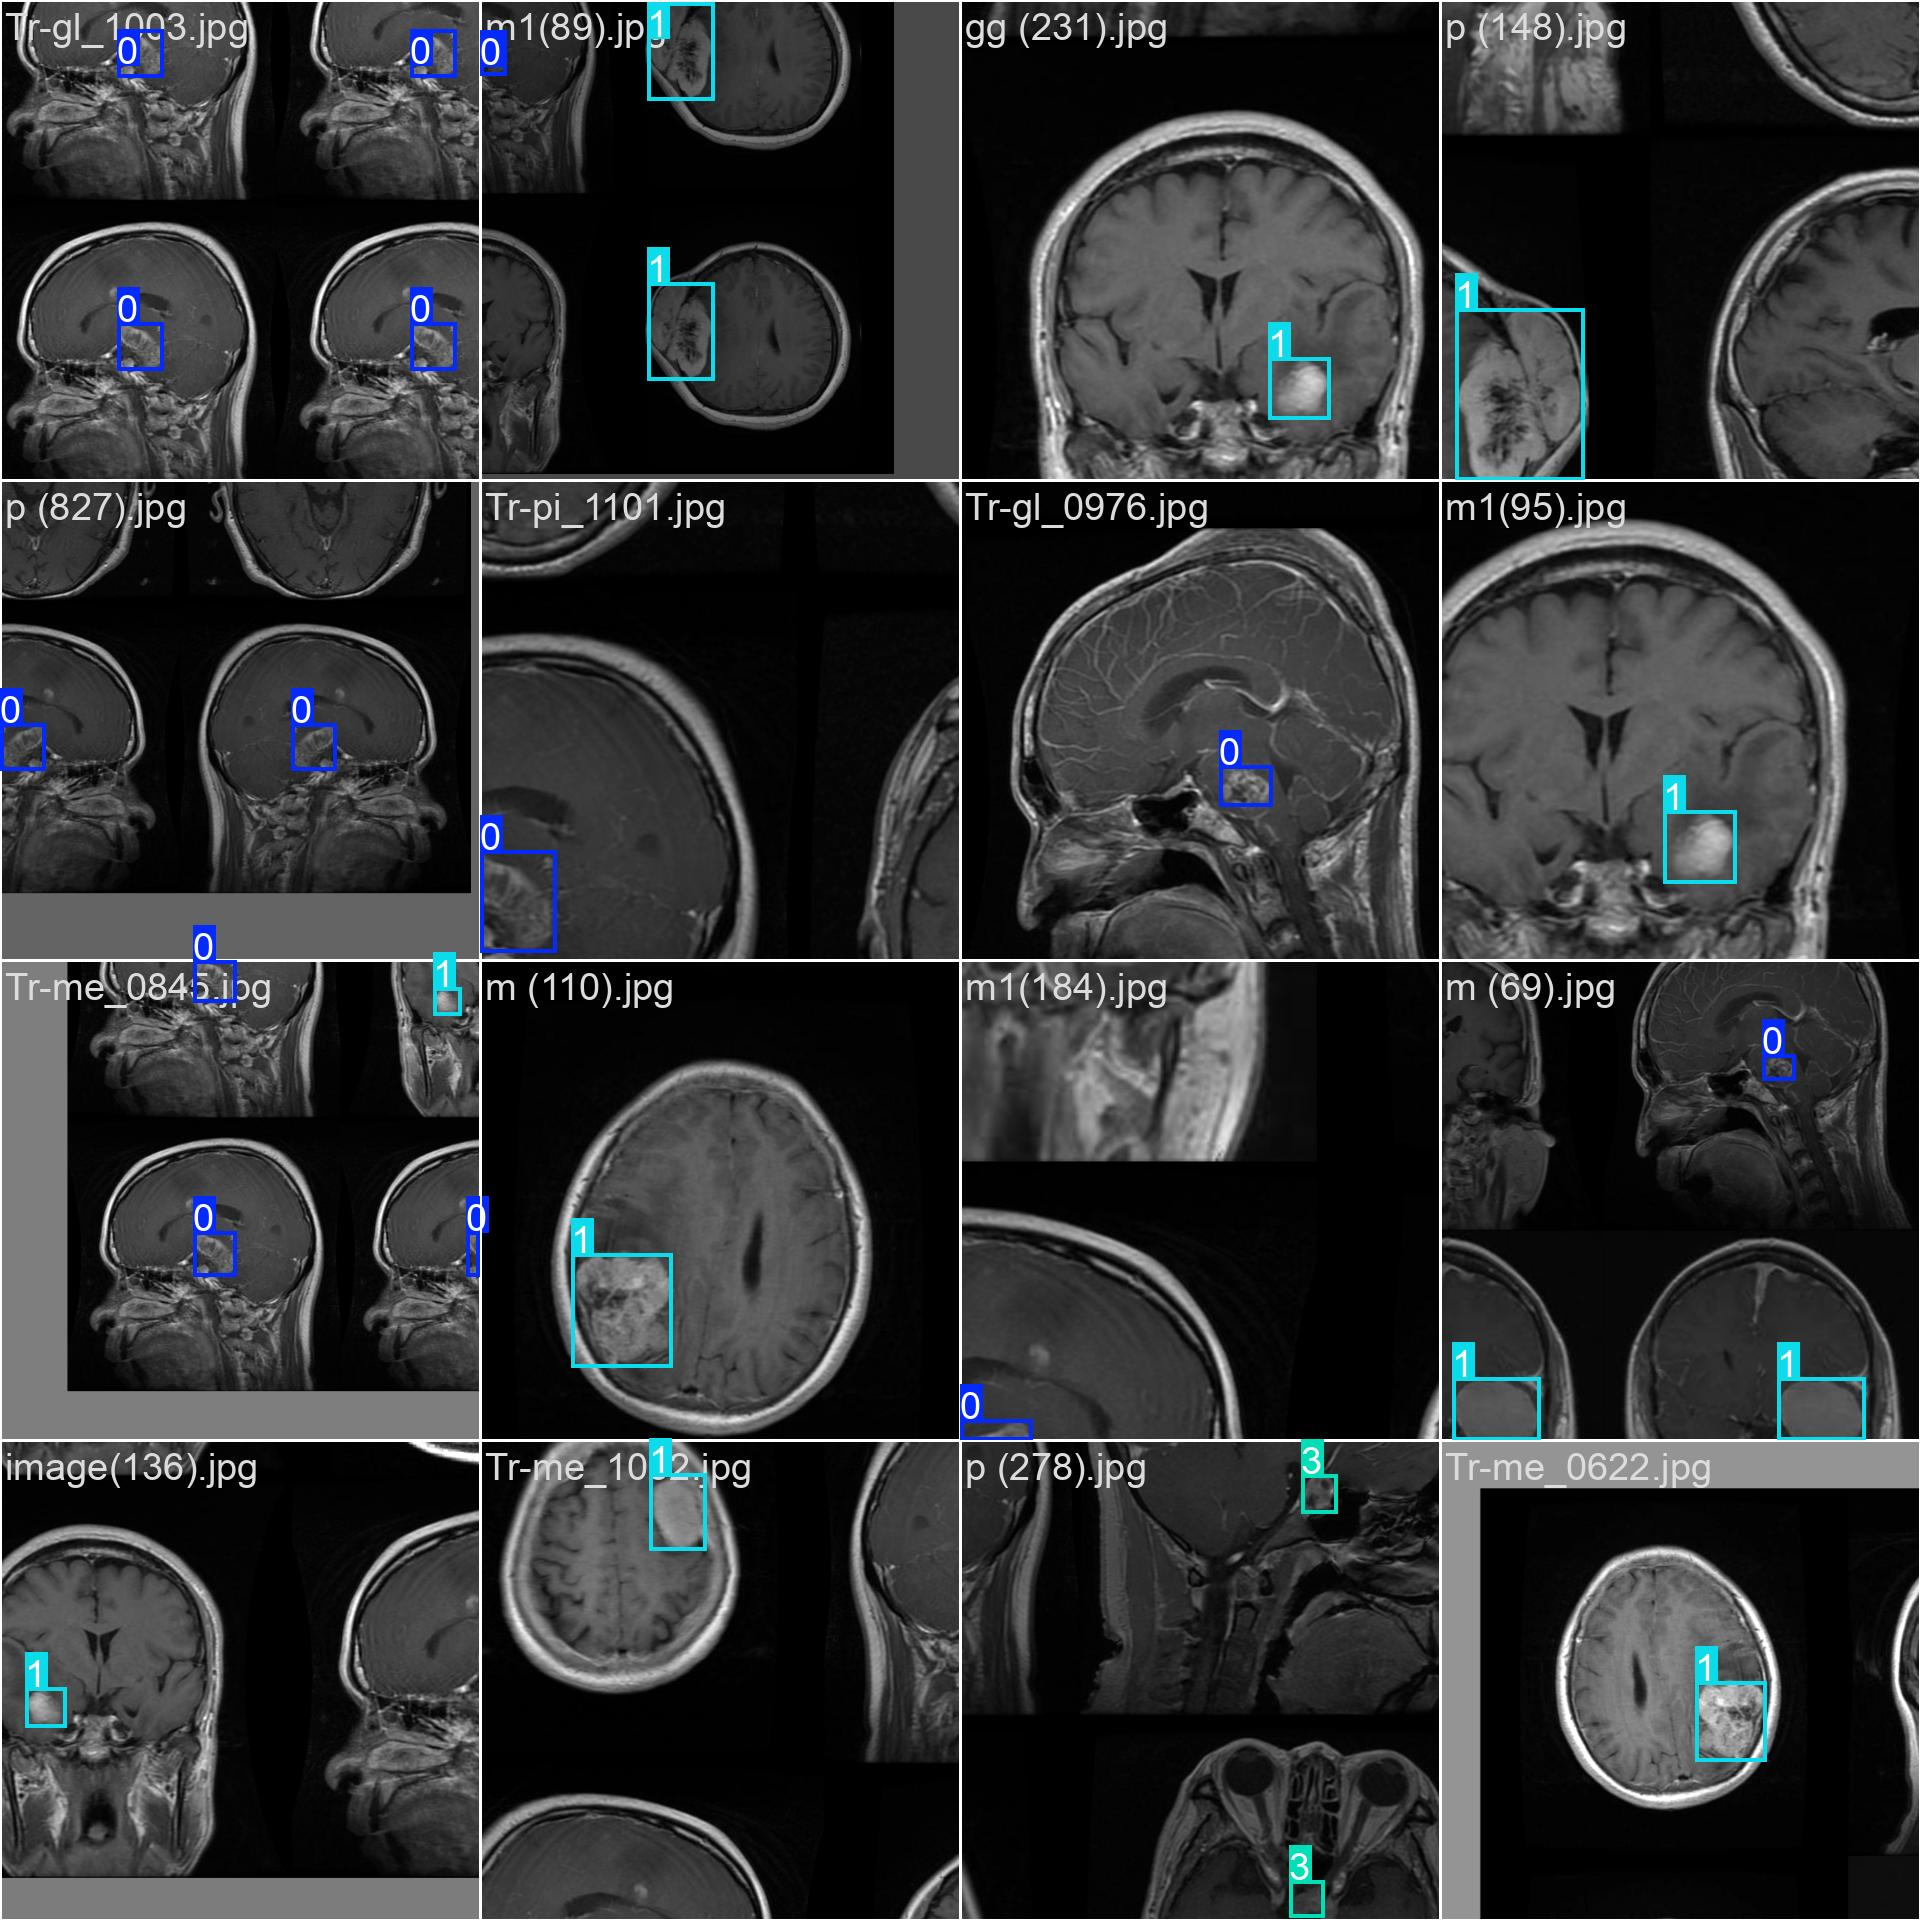

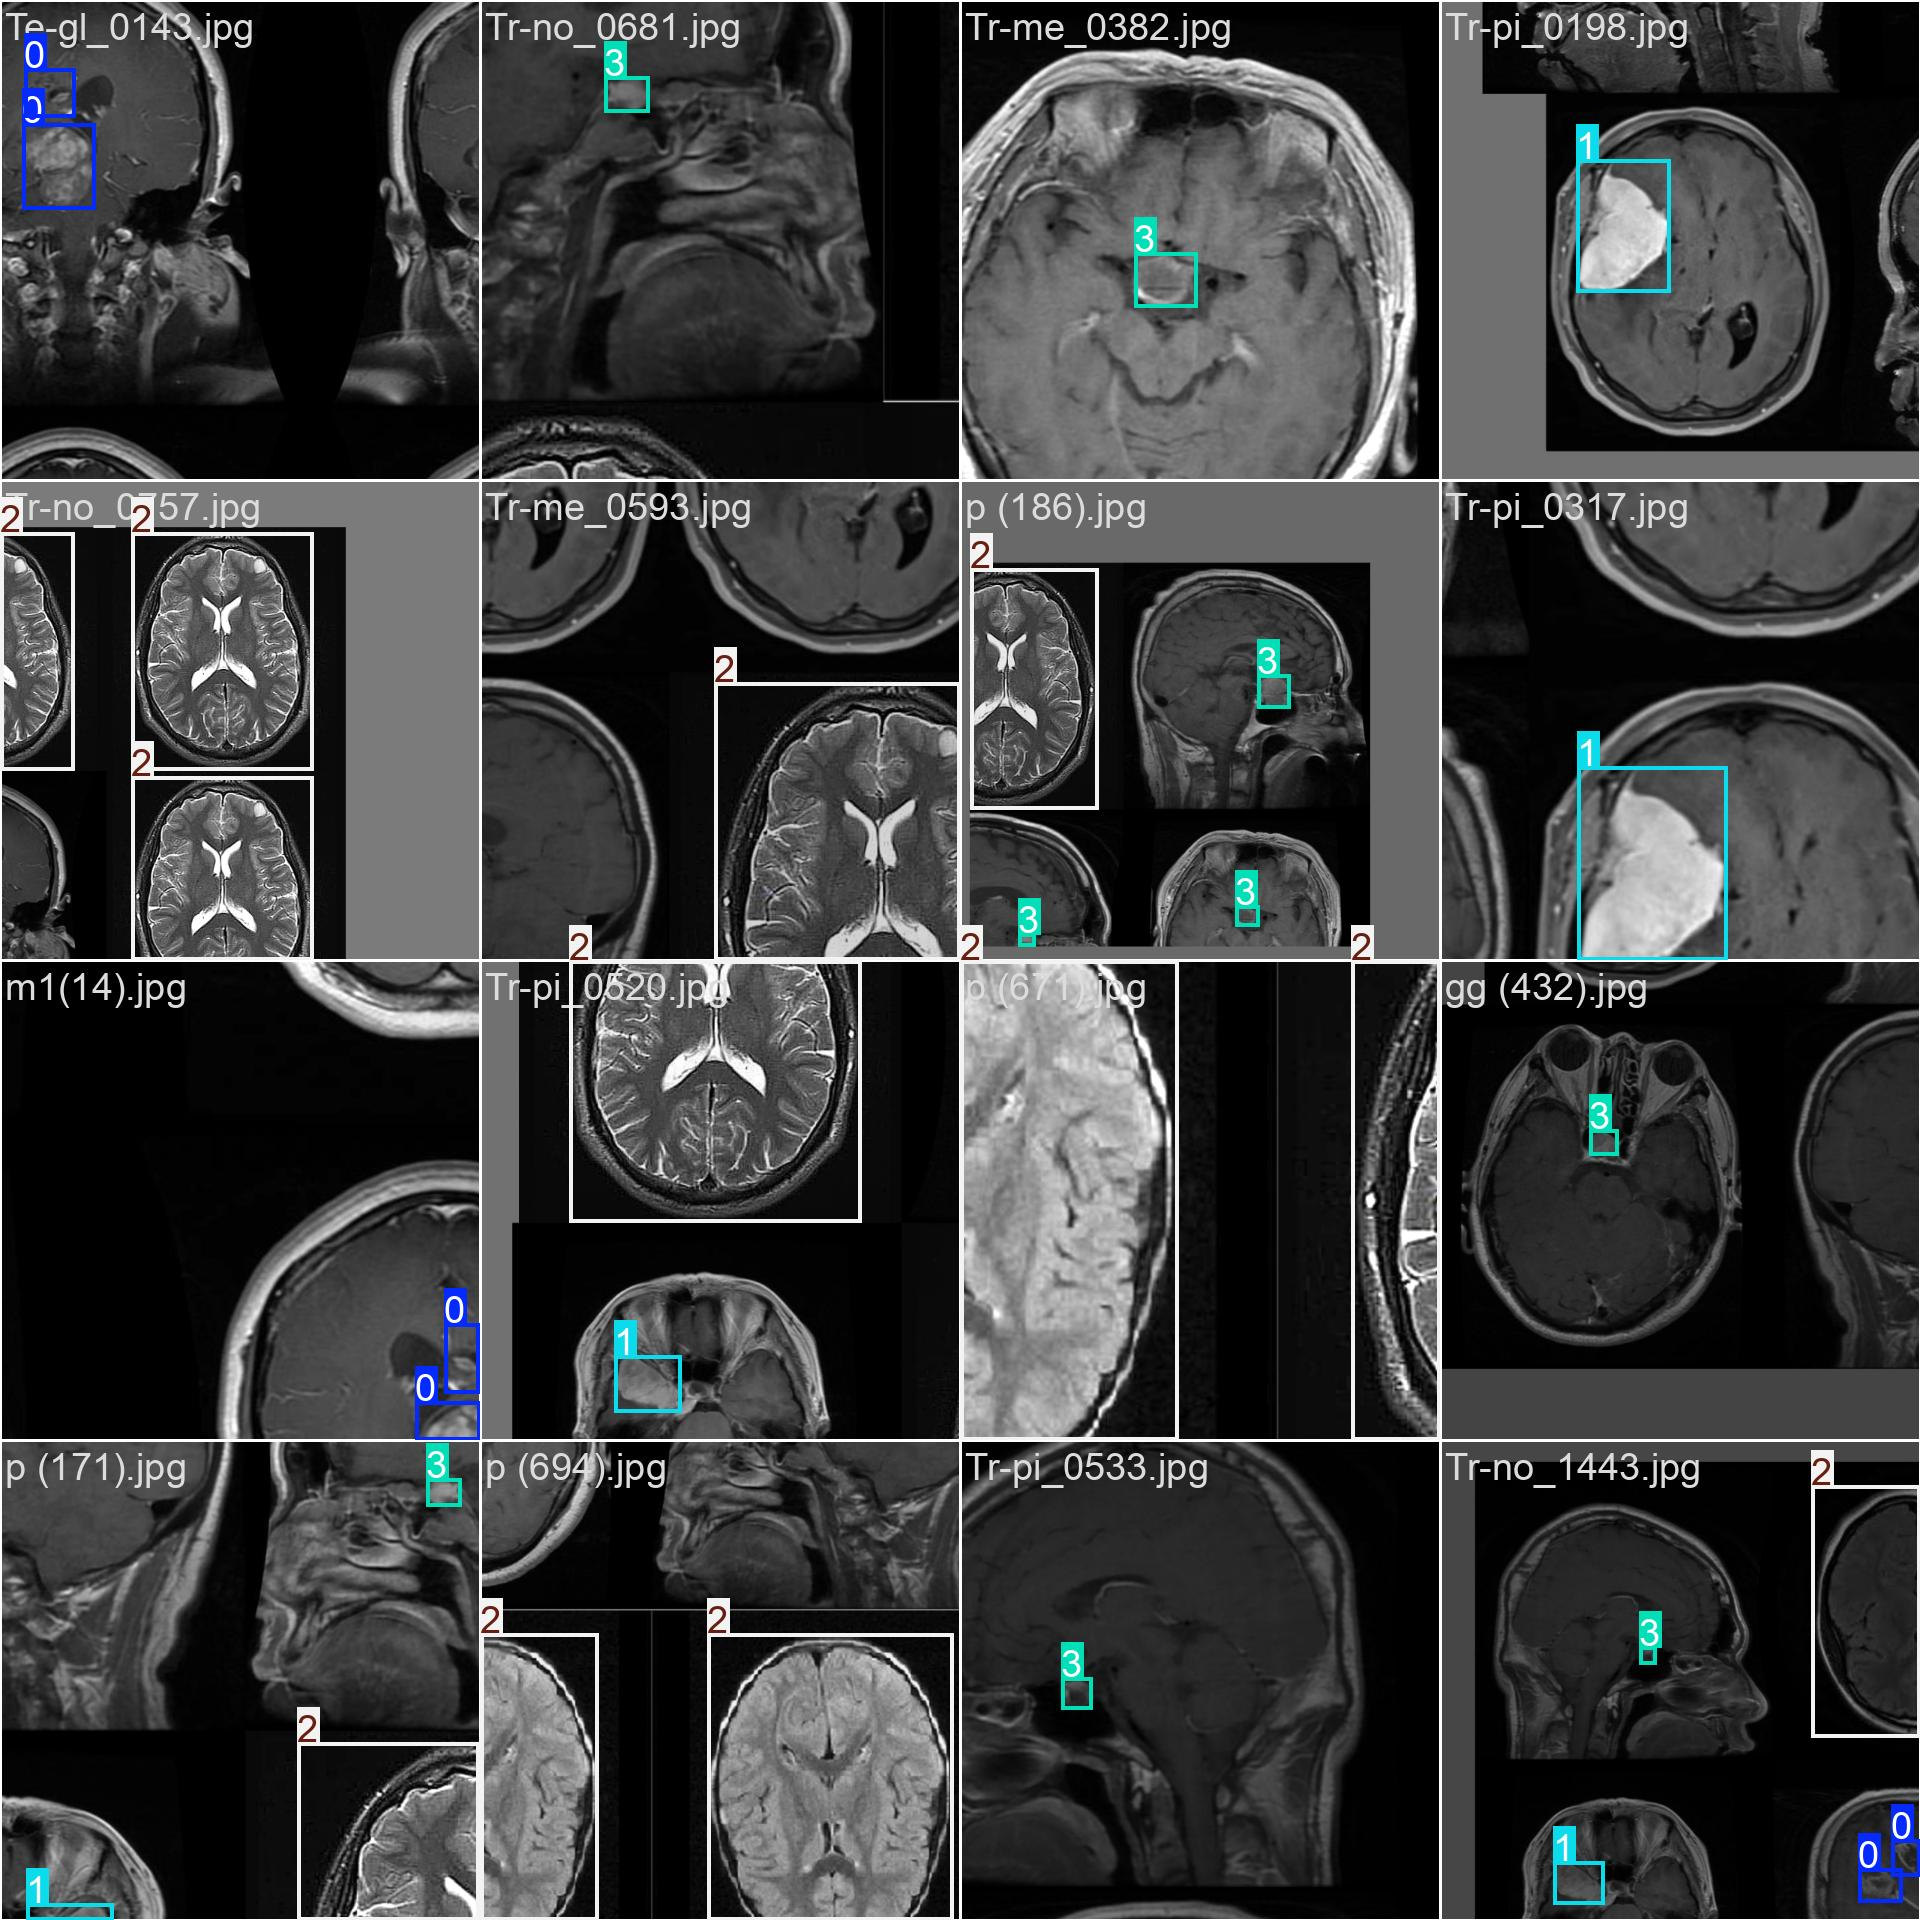

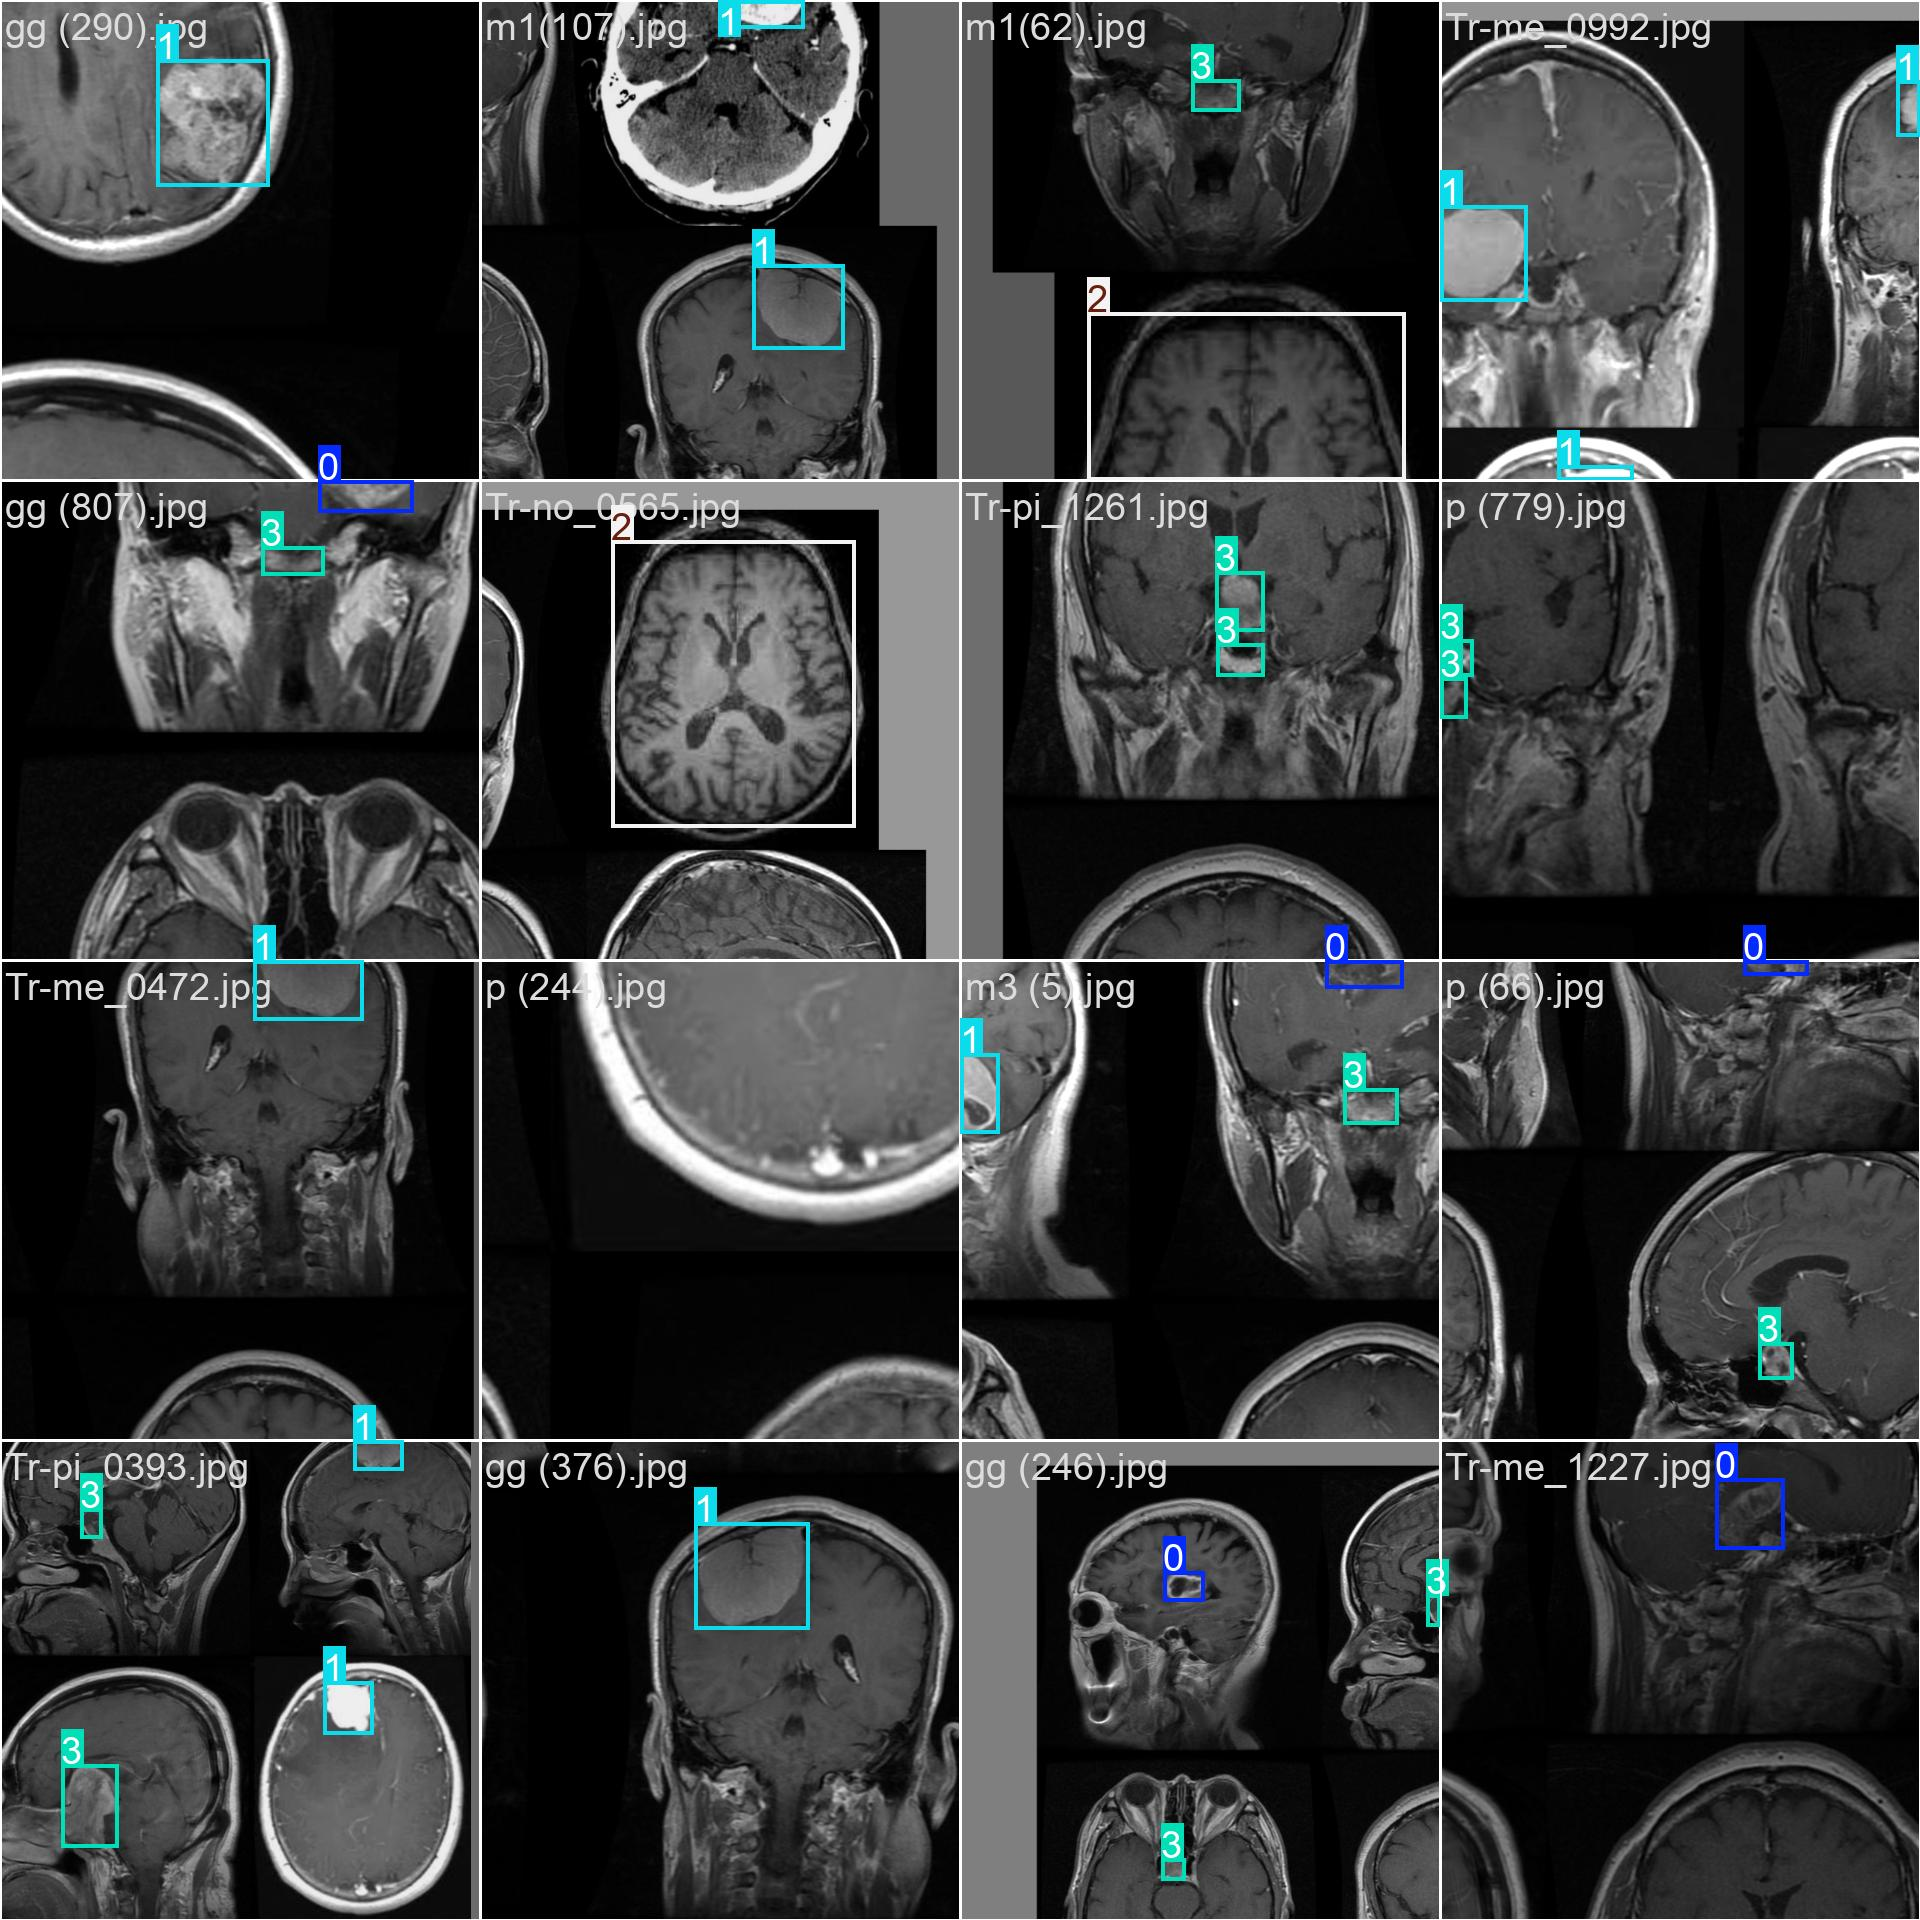

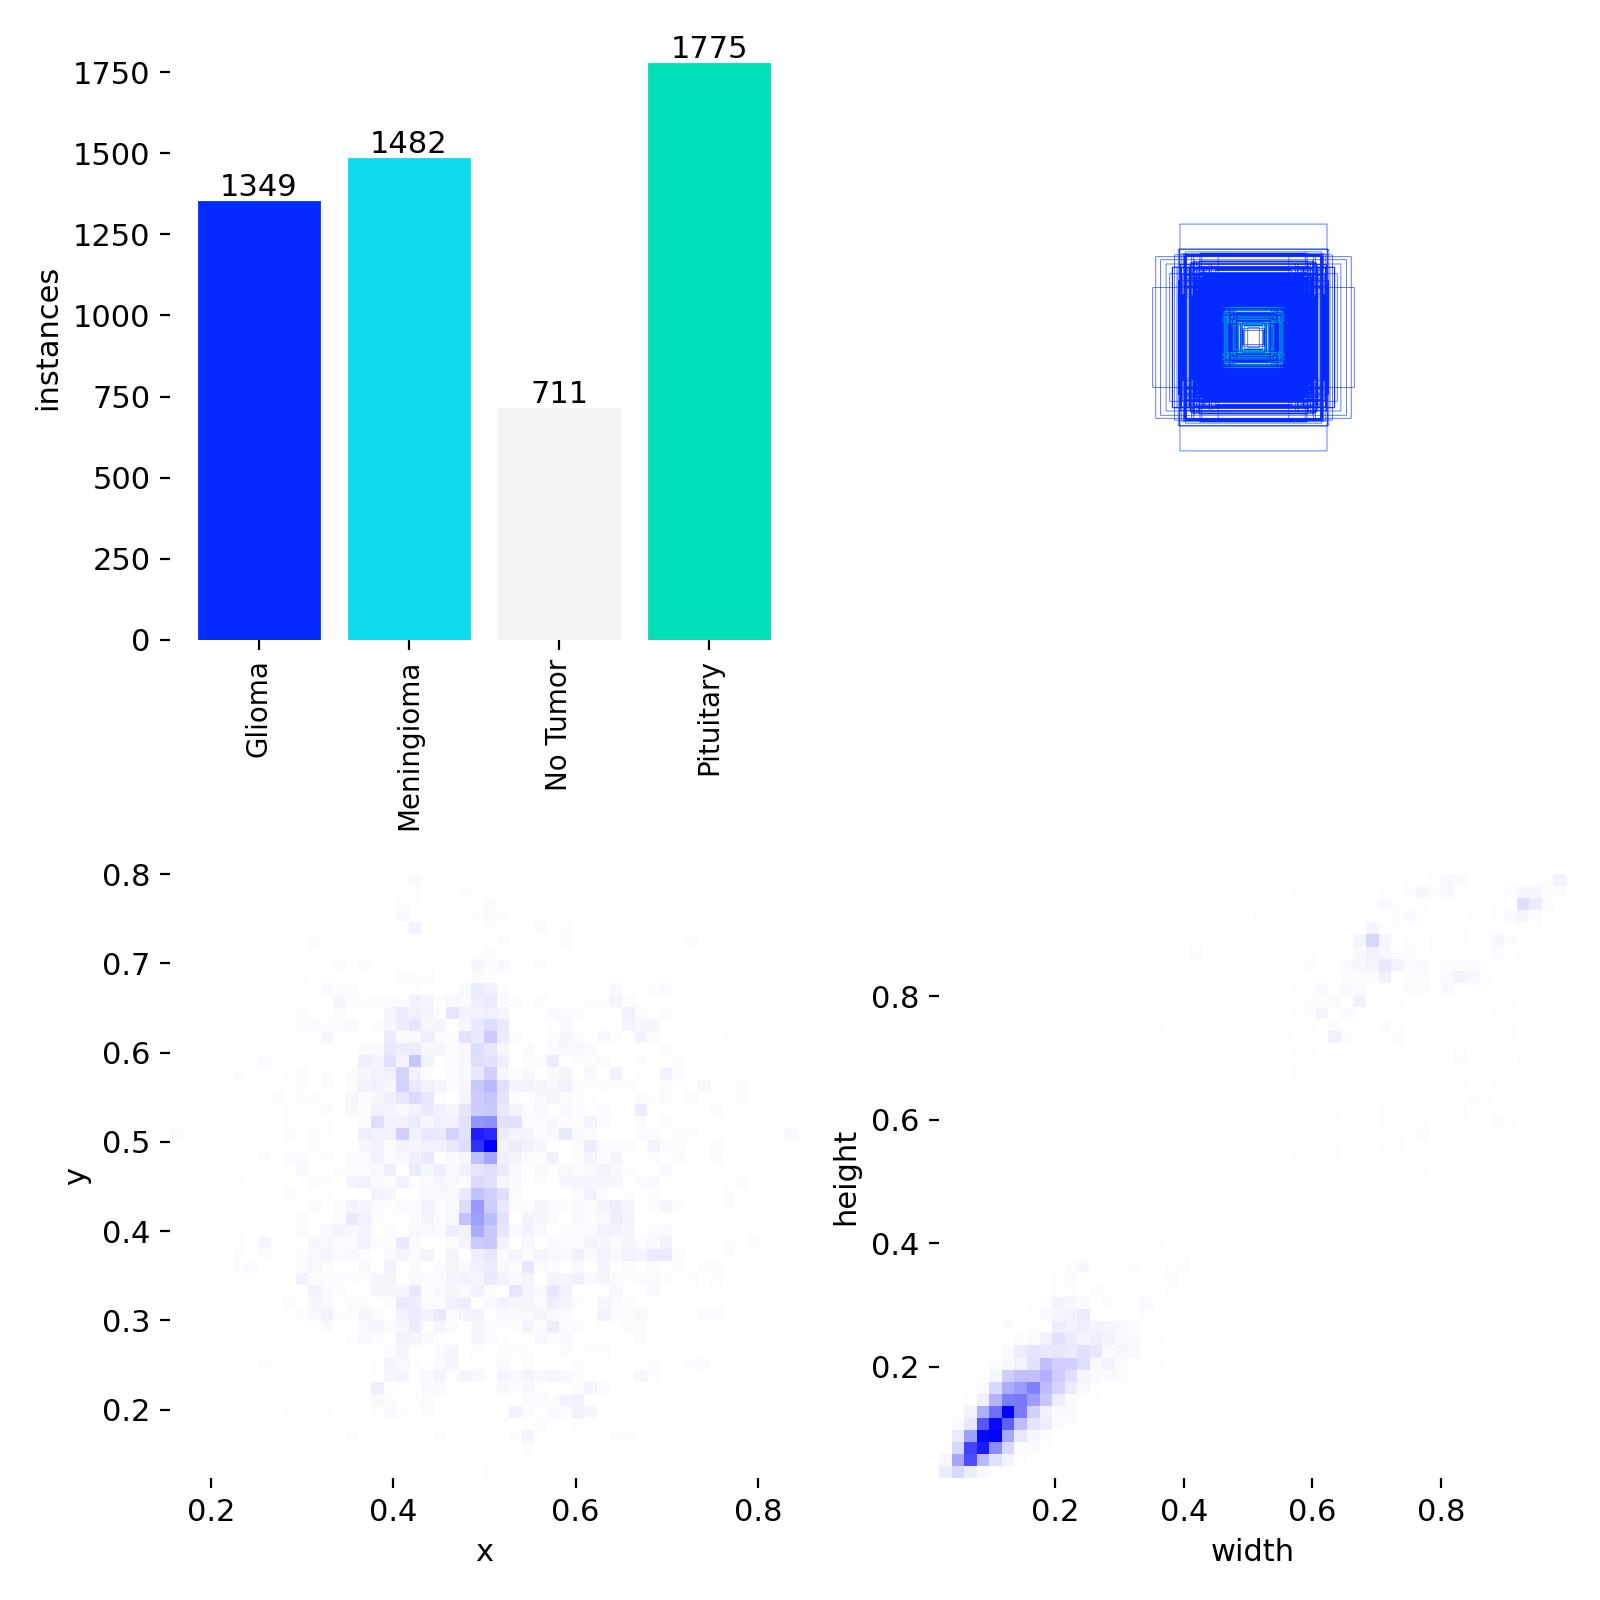

In [9]:
from IPython.display import Image,display
path='/content/runs/detect/train'
image=[f for f in os.listdir(path) if f.endswith('.jpg') or f.endswith('.png')]

for i in range(len(image)):
  display(Image(filename=path+'/'+image[i]))



0: 640x640 1 Glioma, 13.7ms
Speed: 7.6ms preprocess, 13.7ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


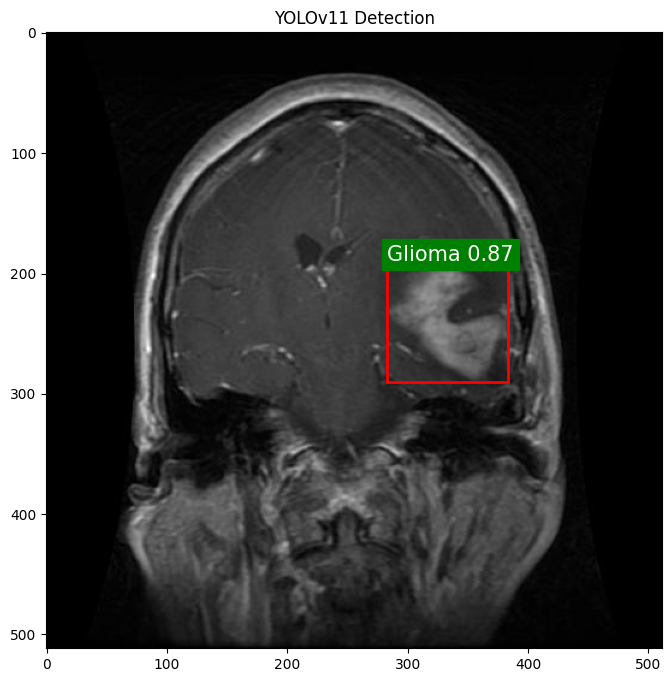


0: 640x640 1 Glioma, 21.2ms
Speed: 5.9ms preprocess, 21.2ms inference, 4.0ms postprocess per image at shape (1, 3, 640, 640)


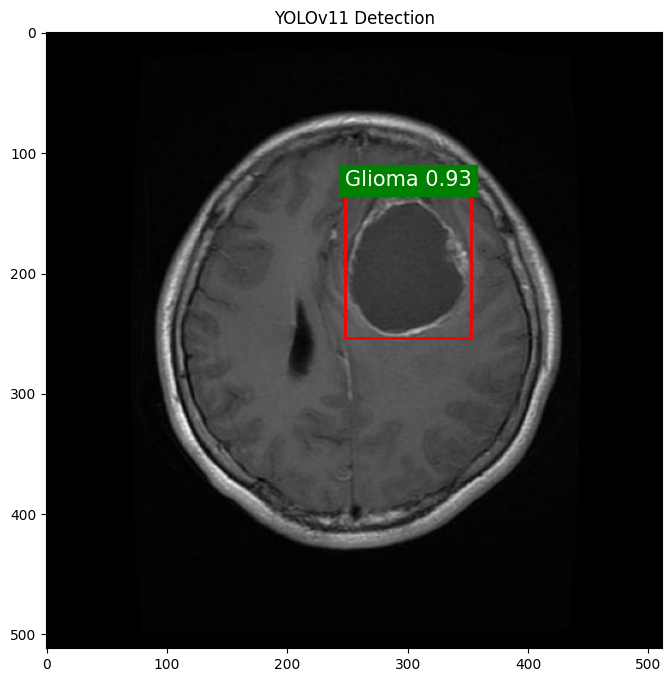


0: 640x640 1 Glioma, 11.2ms
Speed: 4.2ms preprocess, 11.2ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


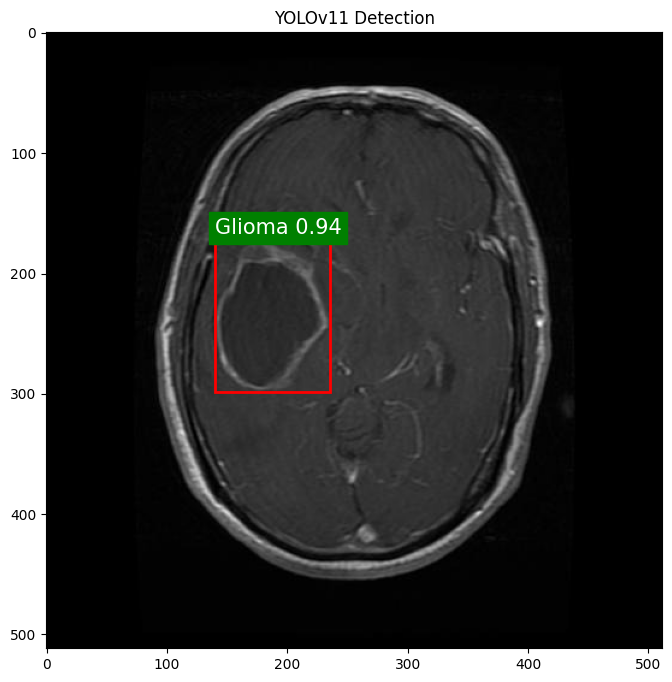


0: 640x640 1 Glioma, 11.6ms
Speed: 3.7ms preprocess, 11.6ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


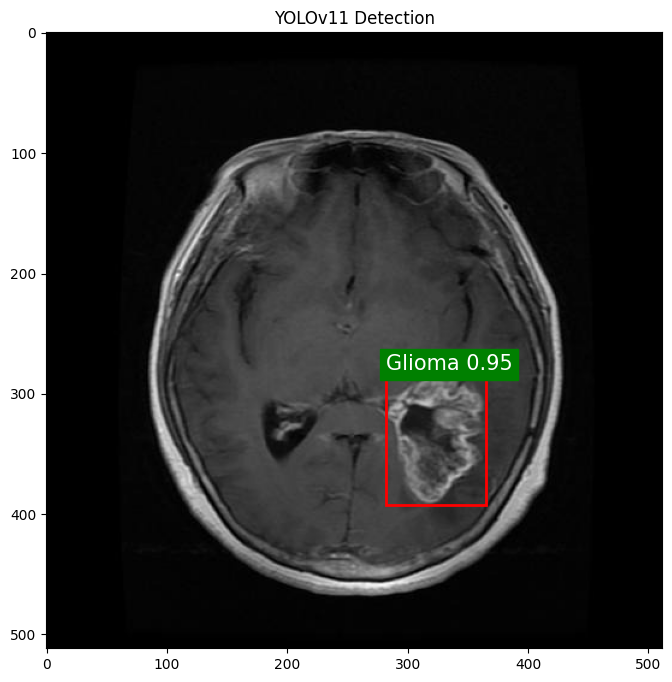


0: 640x640 1 Glioma, 1 Pituitary, 12.1ms
Speed: 3.7ms preprocess, 12.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


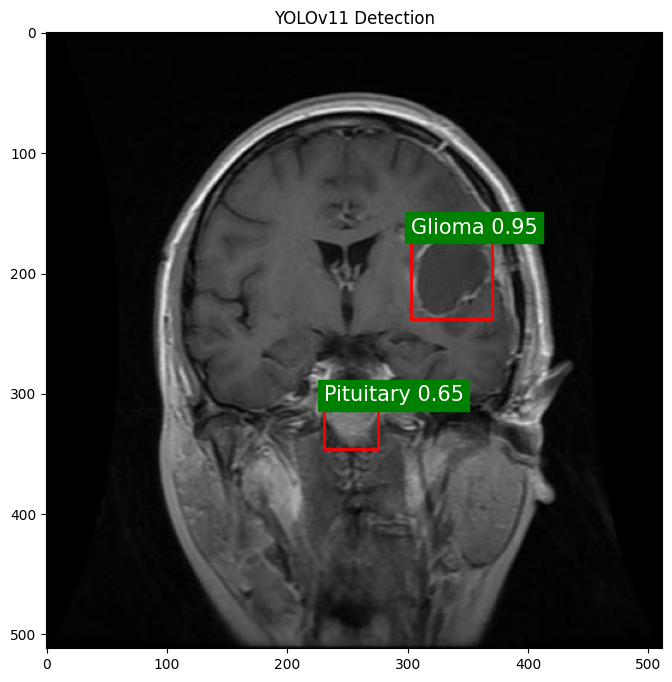


0: 640x640 1 Glioma, 13.7ms
Speed: 4.6ms preprocess, 13.7ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


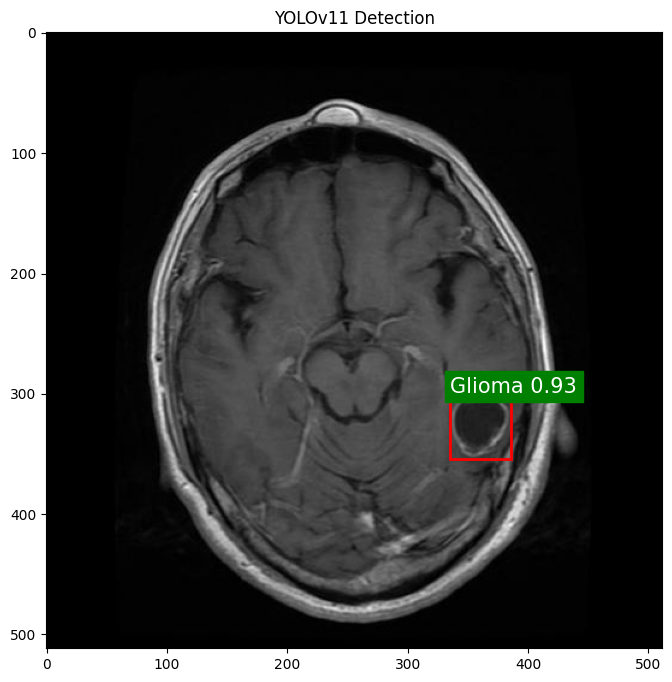


0: 640x640 1 Glioma, 13.6ms
Speed: 3.6ms preprocess, 13.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


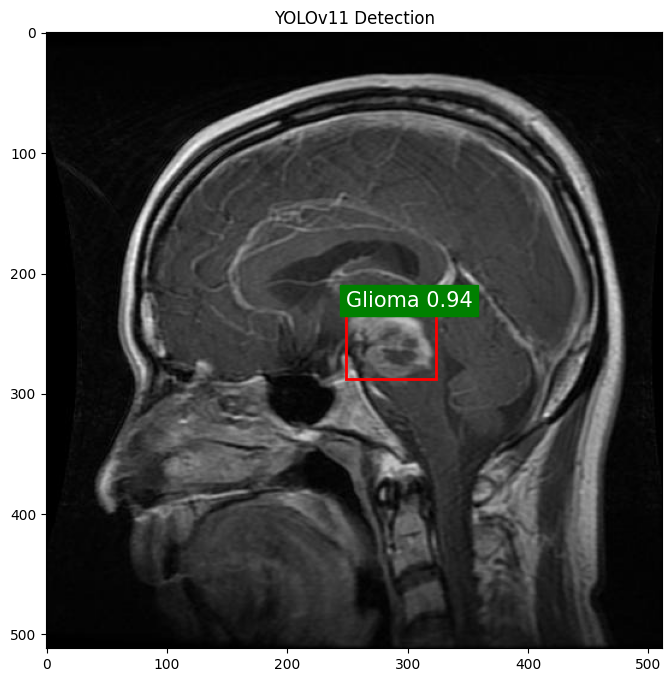


0: 640x640 1 Glioma, 14.0ms
Speed: 4.0ms preprocess, 14.0ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


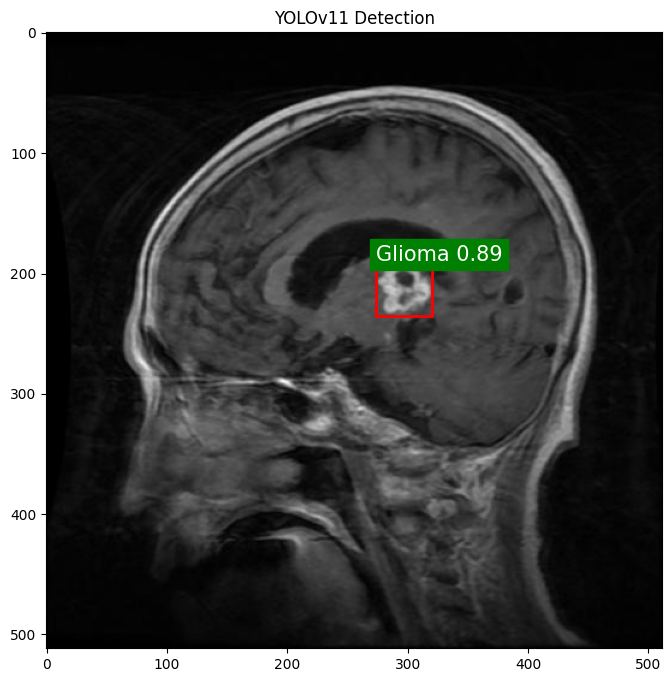


0: 640x640 1 Glioma, 16.3ms
Speed: 4.0ms preprocess, 16.3ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


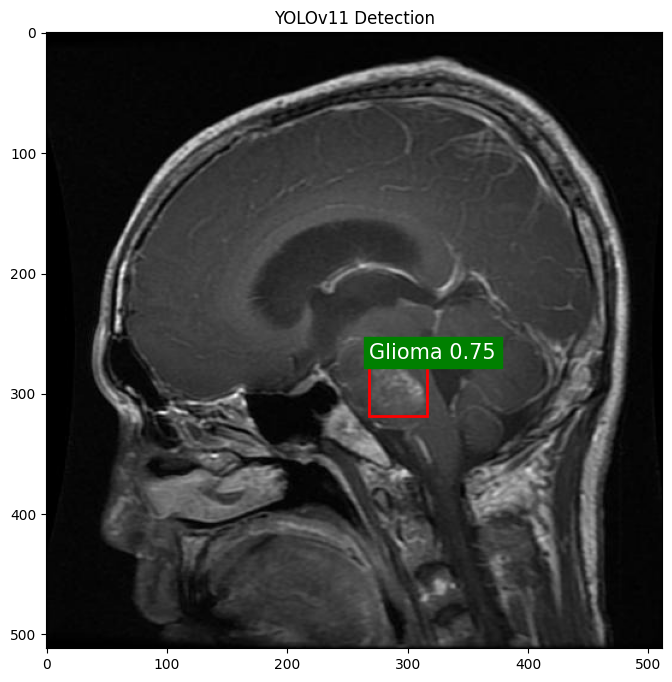


0: 640x640 3 Gliomas, 12.6ms
Speed: 4.4ms preprocess, 12.6ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


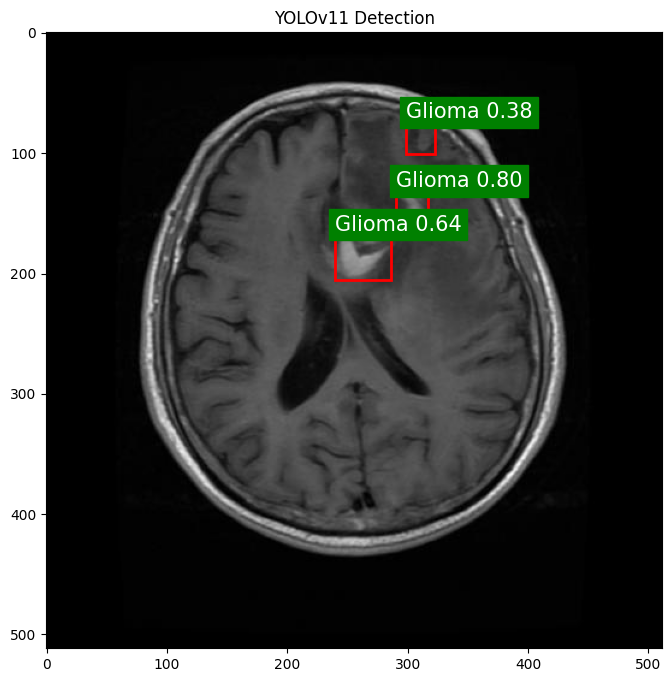


0: 640x640 1 Glioma, 12.8ms
Speed: 3.9ms preprocess, 12.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


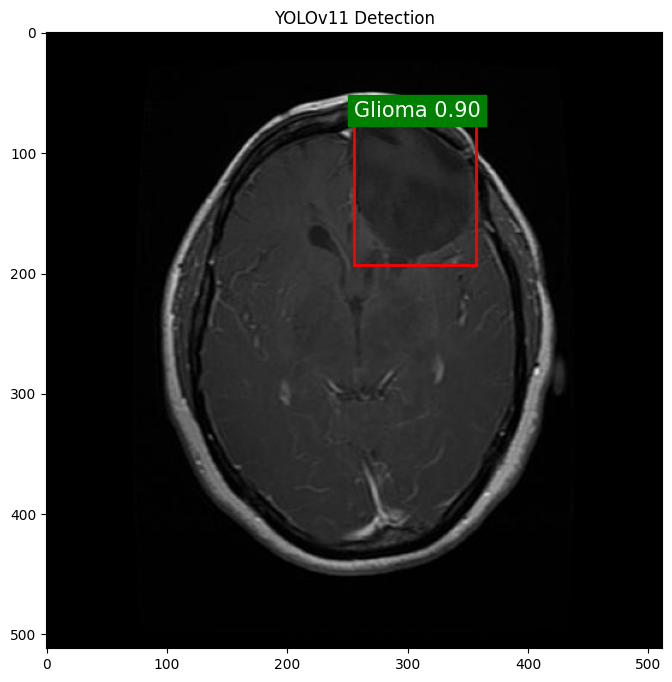


0: 640x640 1 Glioma, 13.1ms
Speed: 3.9ms preprocess, 13.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


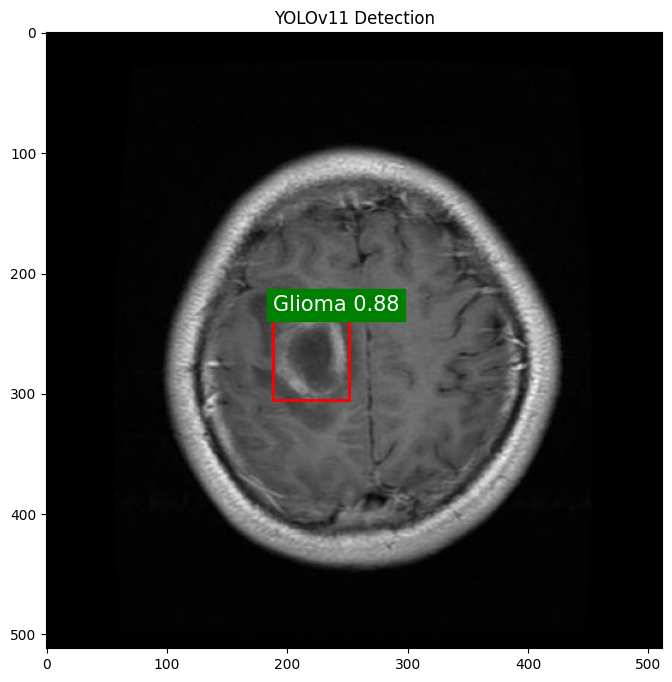


0: 640x640 1 Glioma, 1 Pituitary, 14.1ms
Speed: 4.4ms preprocess, 14.1ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


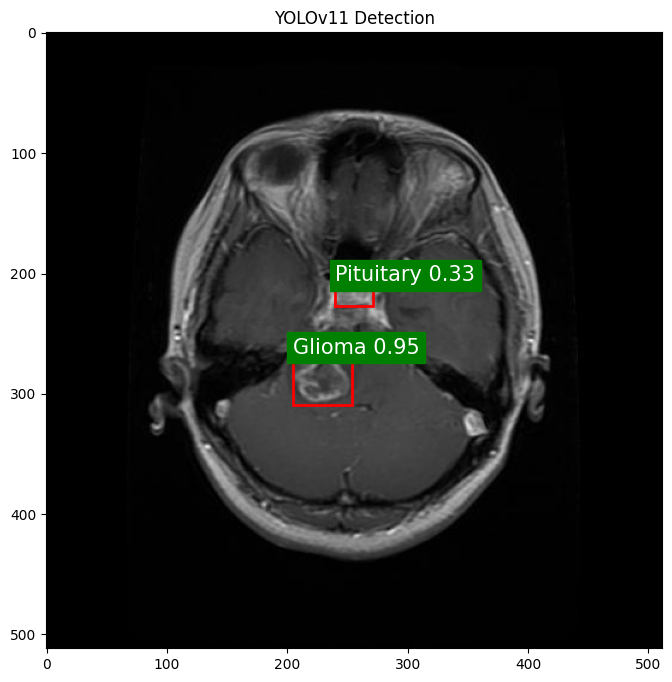


0: 640x640 1 Glioma, 13.1ms
Speed: 4.2ms preprocess, 13.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


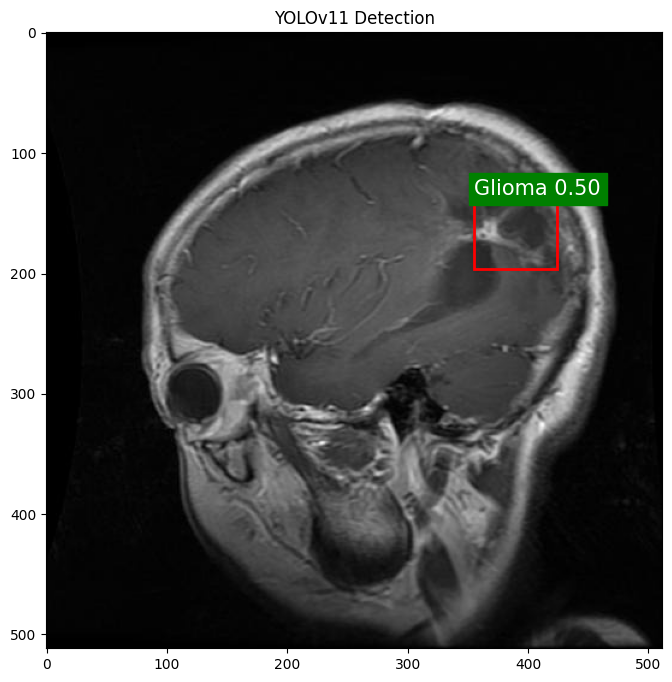


0: 640x640 1 Glioma, 13.3ms
Speed: 4.1ms preprocess, 13.3ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


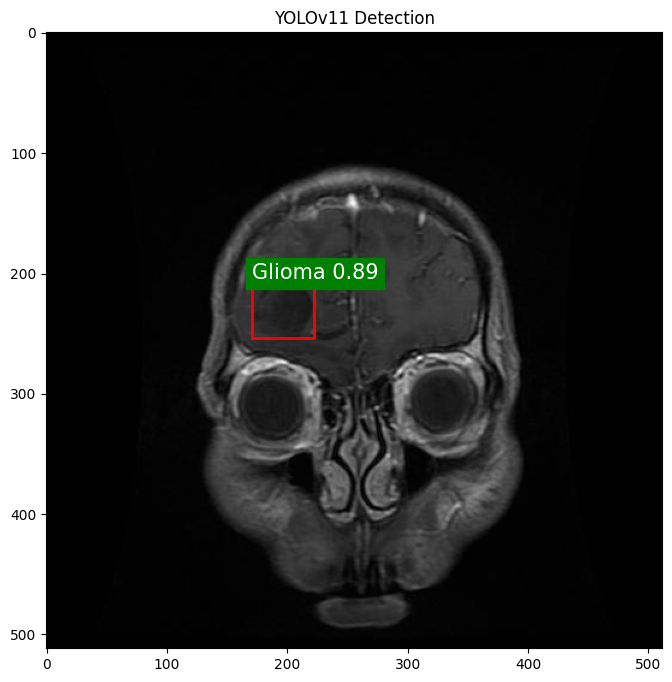


0: 640x640 1 Glioma, 15.3ms
Speed: 4.1ms preprocess, 15.3ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


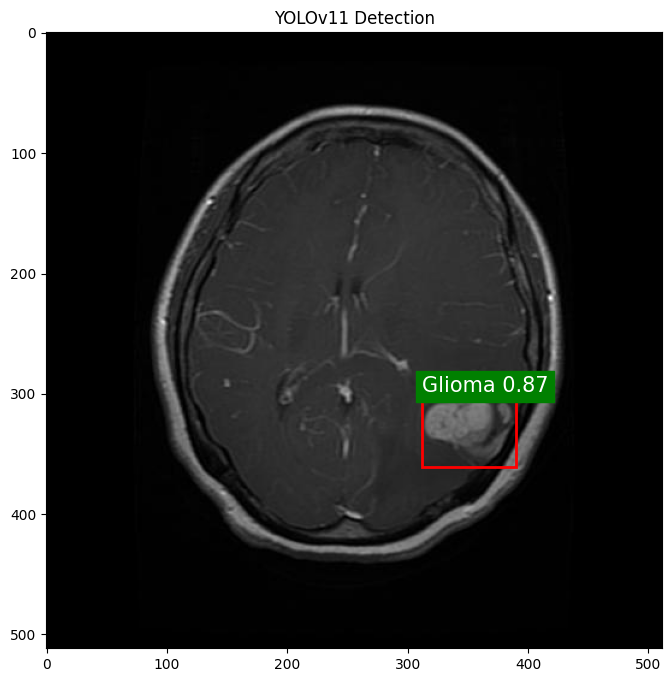


0: 640x640 1 Glioma, 13.7ms
Speed: 4.5ms preprocess, 13.7ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


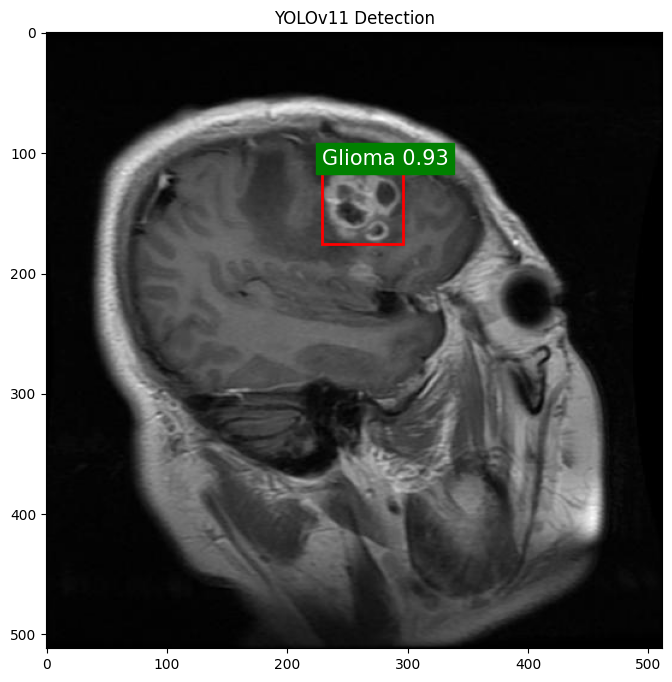


0: 640x640 1 Glioma, 14.2ms
Speed: 4.2ms preprocess, 14.2ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


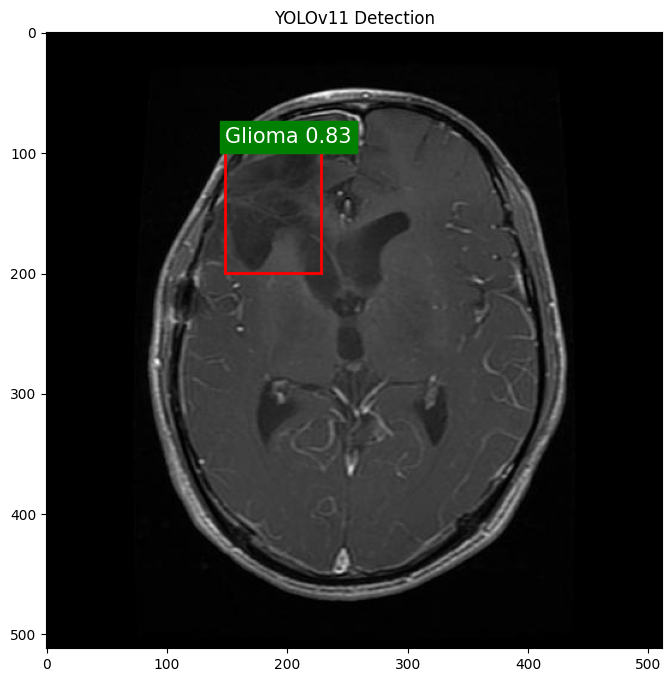


0: 640x640 1 Glioma, 12.1ms
Speed: 4.2ms preprocess, 12.1ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


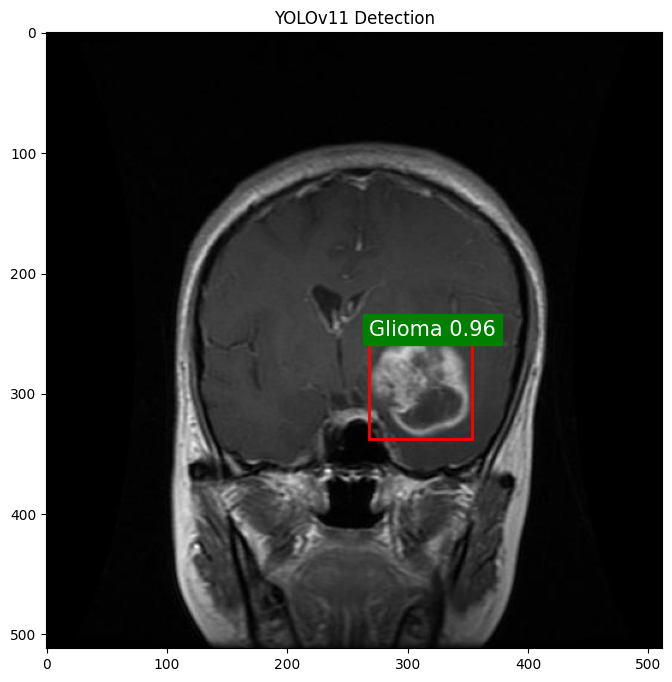


0: 640x640 1 Glioma, 13.2ms
Speed: 3.7ms preprocess, 13.2ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


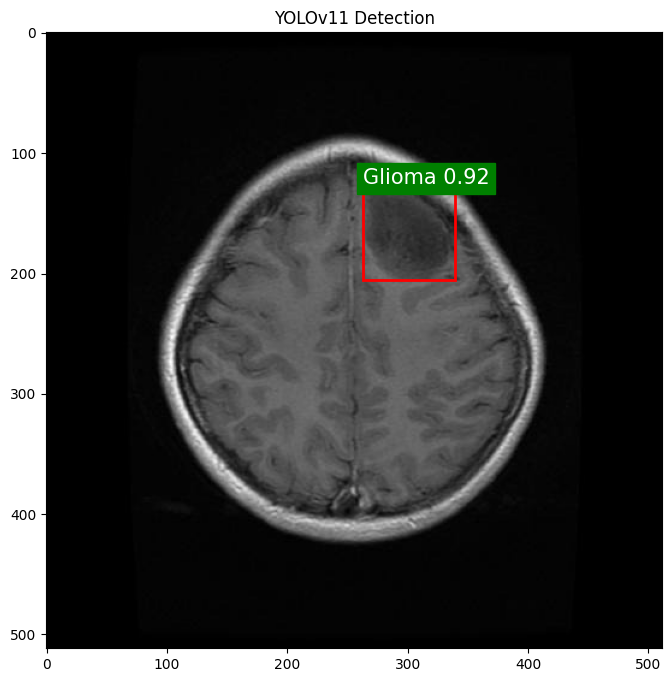


0: 640x640 1 Glioma, 59.0ms
Speed: 14.6ms preprocess, 59.0ms inference, 3.8ms postprocess per image at shape (1, 3, 640, 640)


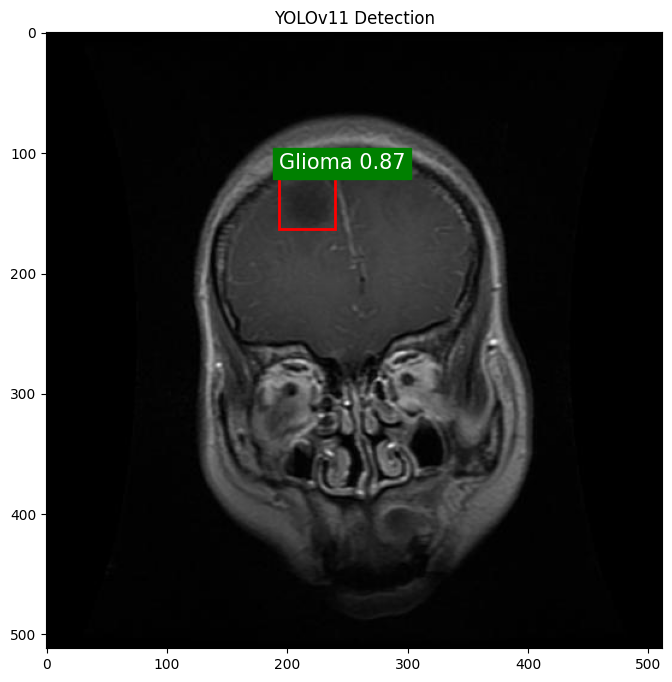


0: 640x640 1 Glioma, 15.1ms
Speed: 4.0ms preprocess, 15.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


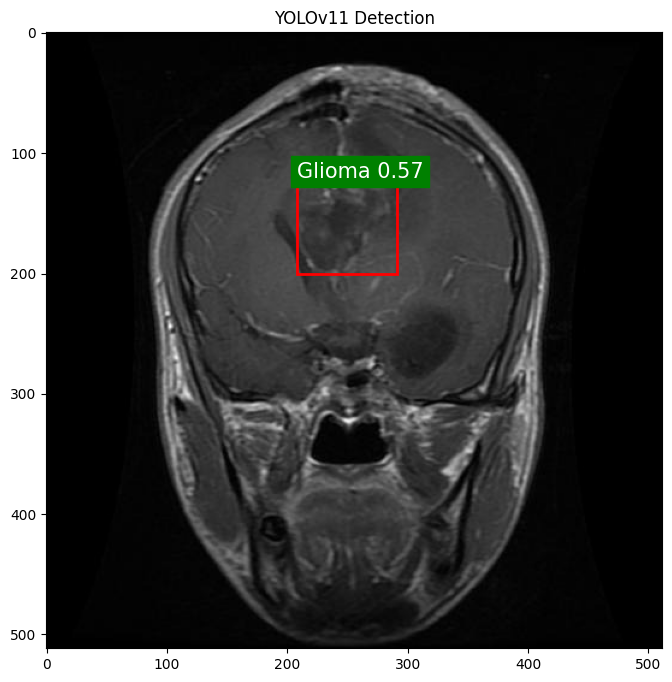


0: 640x640 1 Glioma, 1 Pituitary, 14.3ms
Speed: 4.8ms preprocess, 14.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


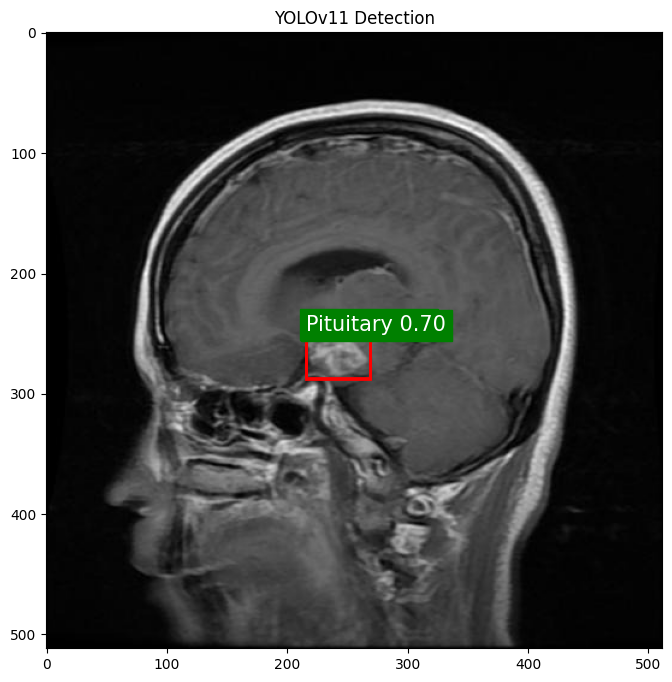


0: 640x640 1 Glioma, 13.1ms
Speed: 4.3ms preprocess, 13.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


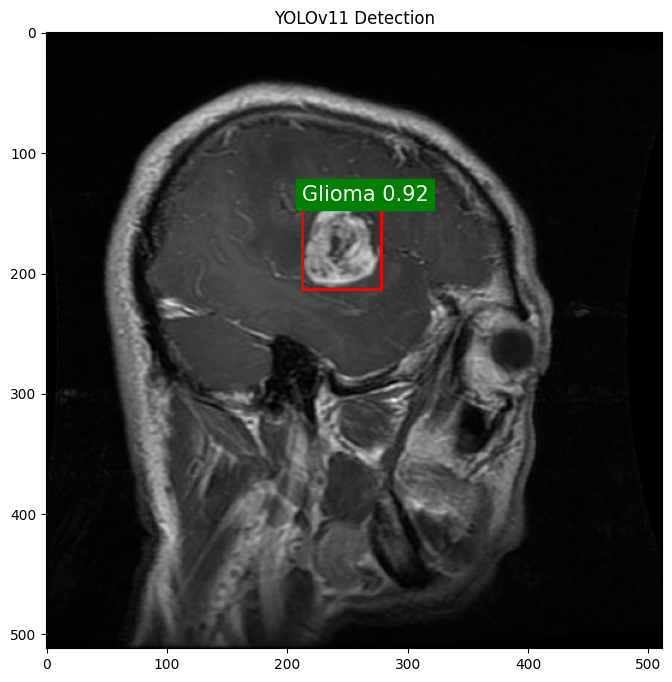


0: 640x640 1 Glioma, 12.1ms
Speed: 4.6ms preprocess, 12.1ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


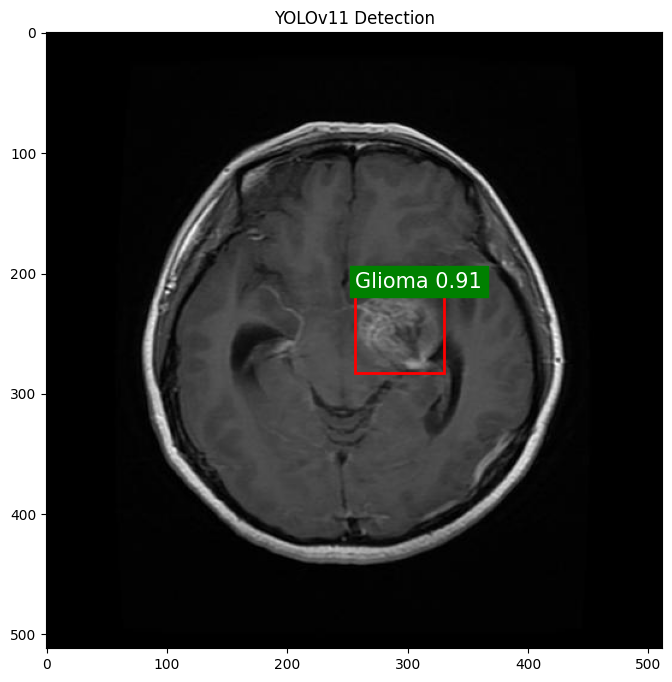


0: 640x640 1 Glioma, 15.2ms
Speed: 4.7ms preprocess, 15.2ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


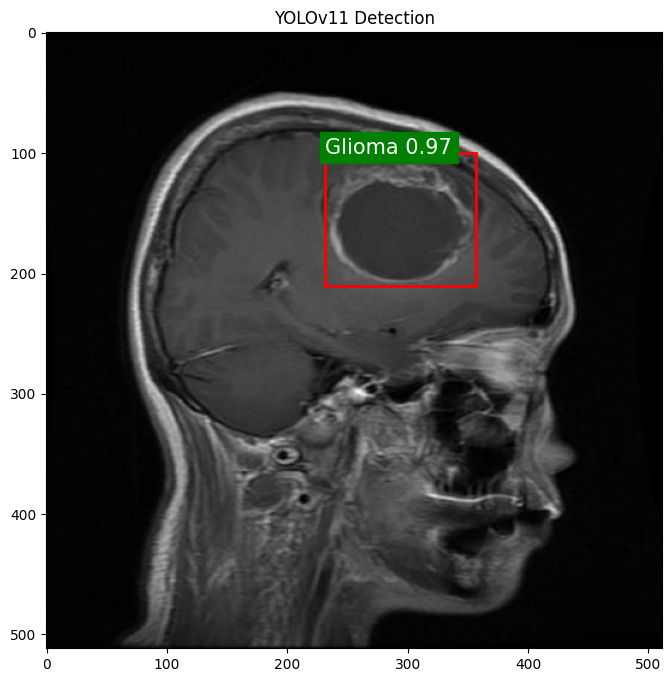


0: 640x640 1 Glioma, 11.8ms
Speed: 4.1ms preprocess, 11.8ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


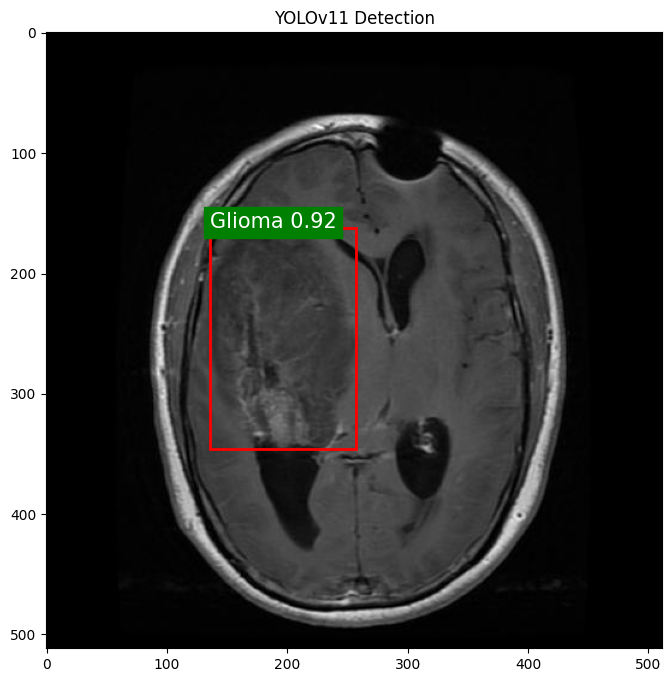


0: 640x640 4 Gliomas, 15.4ms
Speed: 4.8ms preprocess, 15.4ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


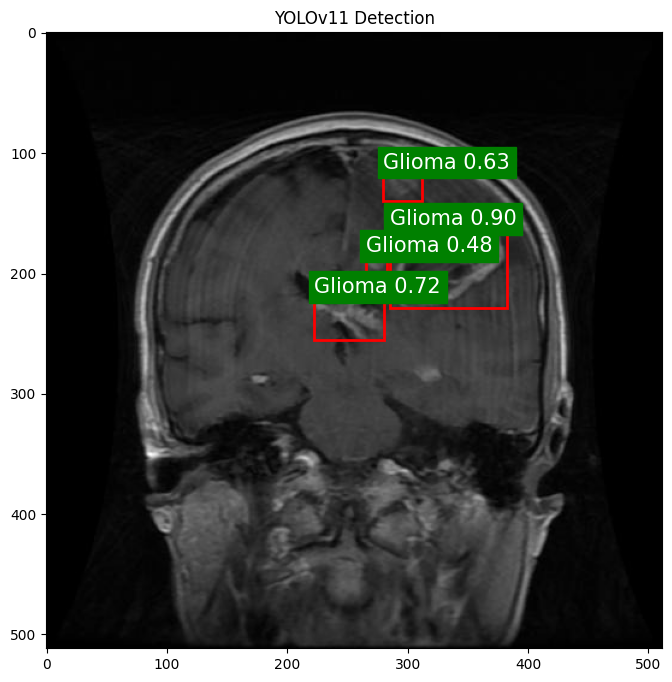


0: 640x640 2 Gliomas, 51.0ms
Speed: 10.7ms preprocess, 51.0ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


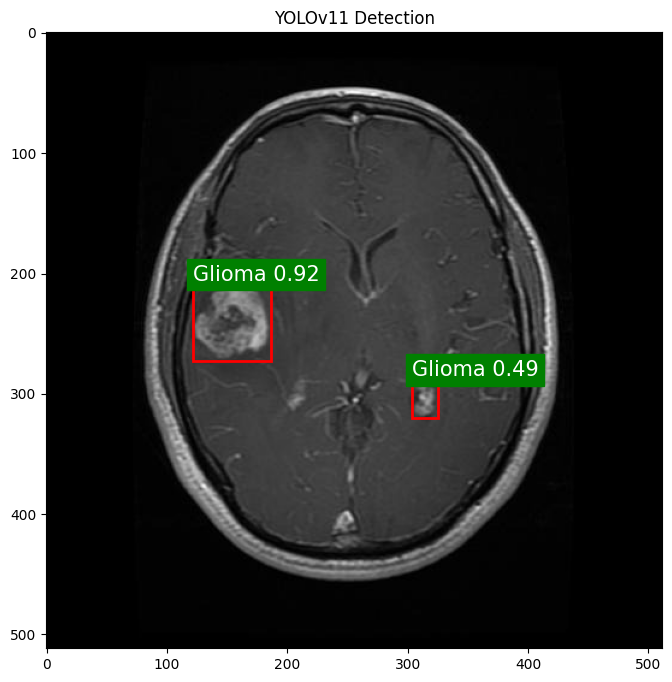


0: 640x640 1 Glioma, 53.2ms
Speed: 13.5ms preprocess, 53.2ms inference, 6.1ms postprocess per image at shape (1, 3, 640, 640)


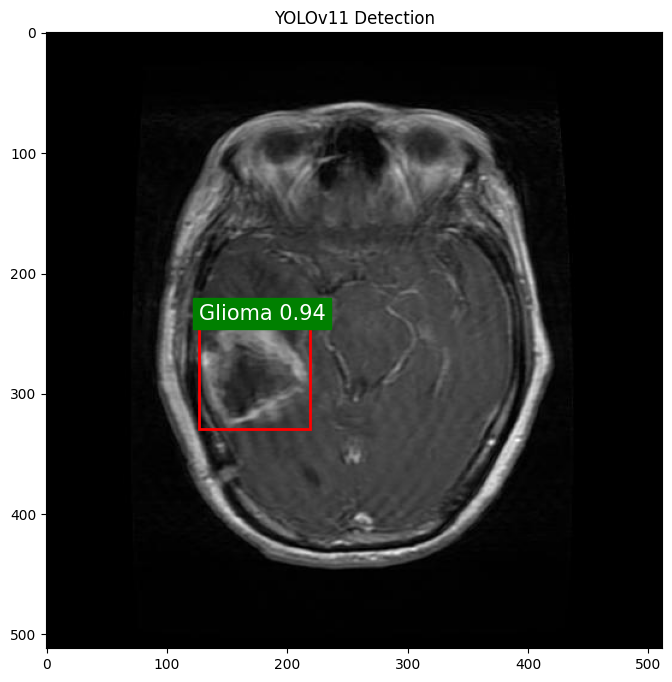


0: 640x640 1 Glioma, 20.6ms
Speed: 5.7ms preprocess, 20.6ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


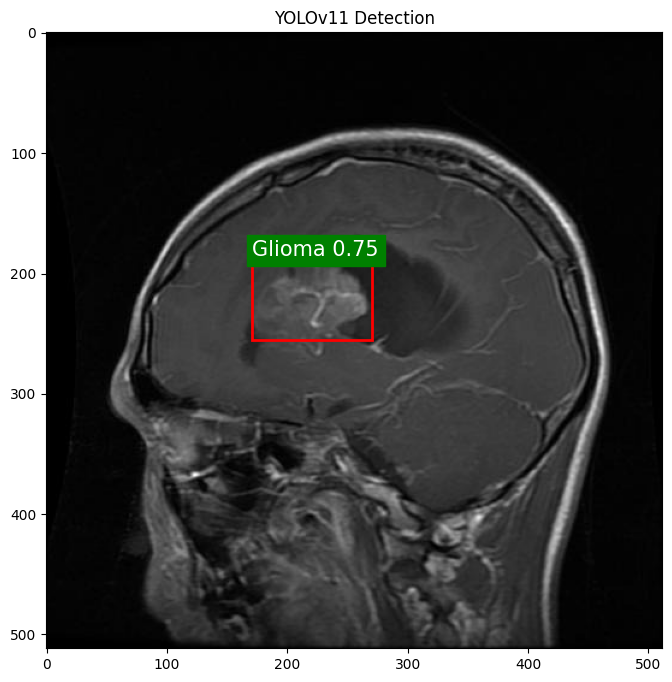


0: 640x640 1 Glioma, 16.6ms
Speed: 6.5ms preprocess, 16.6ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


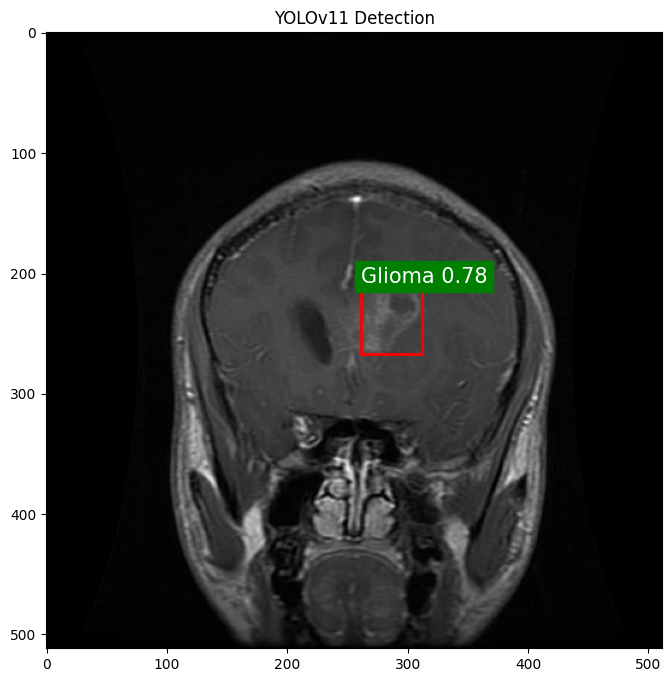


0: 640x640 2 Gliomas, 1 Pituitary, 12.9ms
Speed: 4.7ms preprocess, 12.9ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


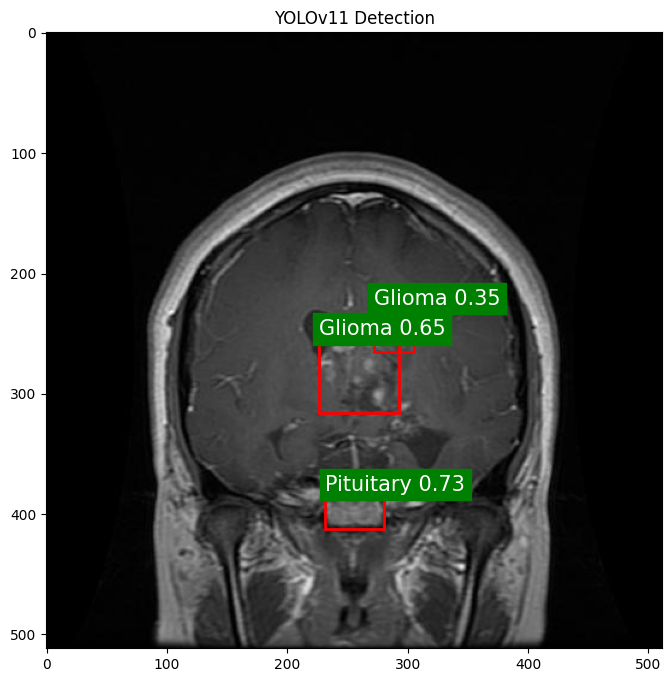


0: 640x640 2 Gliomas, 14.2ms
Speed: 3.9ms preprocess, 14.2ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


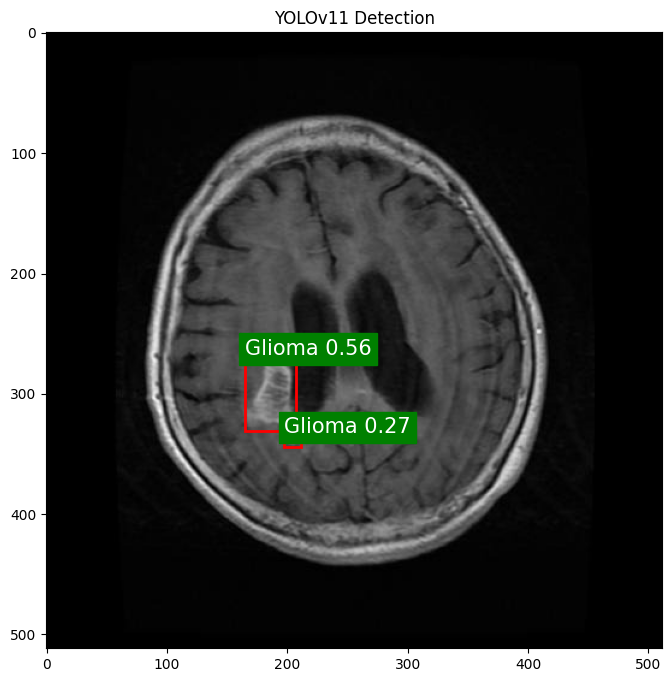


0: 640x640 1 Meningioma, 13.9ms
Speed: 3.9ms preprocess, 13.9ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


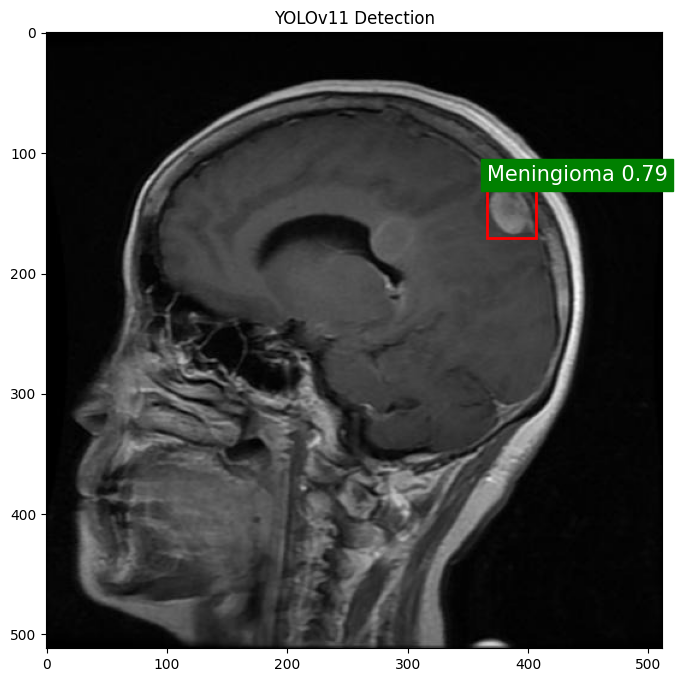

In [11]:
def display_pred(images, model):
    for i in range(35):
        img = images[i]
        result = model.predict(img)[0]

        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        ax = plt.gca()

        for detection in result.boxes:
            x1, y1, x2, y2 = detection.xyxy[0].cpu().numpy()
            conf = detection.conf[0].cpu().numpy()
            cls = detection.cls[0].cpu().numpy()
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            plt.text(x1, y1, f"{classes[int(cls)]} {conf:.2f}", color='white', fontsize=15, backgroundcolor='green')

        plt.title(f'YOLOv11 Detection')
        plt.show()
display_pred(val_images,model)

In [12]:
model.save("tumor1.pt")